# Commodity Bubble Detection — ML Pipeline (LPPLS Labels)

Same pipeline as `bubble_detection_ml.ipynb` but uses **LPPLS-generated bubble labels**
from `R/df_master_lppls.csv` (produced by `notebooks/analysis/lppls_data_prep.ipynb`).

**Key difference from the GSADF notebook:**
- LPPLS labels are substantially sparser (~1–2% vs 1–50% for GSADF). This means:
  - Fewer positive examples per CV fold → some folds may be skipped (guarded)
  - Higher class imbalance → `balanced` weights become more critical
  - Model AUC estimates are noisier — interpret with caution
  - A metal with fewer than 10 total bubble days triggers an explicit warning

**Ground truth:** LPPLS confidence ≥ 0.3 (positive direction only), trend-filtered.

**Models:** LASSO (linear benchmark) | Random Forest | LightGBM


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os, warnings
from itertools import product
import random
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import roc_auc_score, confusion_matrix, roc_curve
from sklearn.preprocessing import StandardScaler
import lightgbm as lgb
import shap

plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.facecolor'] = 'white'
os.makedirs('outputs', exist_ok=True)

# Guard: make sure the LPPLS master file exists before continuing
LPPLS_CSV = '../R/df_master_lppls.csv'
assert os.path.exists(LPPLS_CSV), (
    f'File not found: {LPPLS_CSV}\n'
    'Run notebooks/analysis/lppls_data_prep.ipynb first to generate it.'
)
print('All packages loaded. LPPLS master file found.')


All packages loaded. LPPLS master file found.


## 1. Load LPPLS Master Data


In [2]:
df_master = pd.read_csv(LPPLS_CSV, sep=';', decimal=',', index_col=0)
df_master['Date'] = pd.to_datetime(df_master['Date'])
df_master = df_master.sort_values('Date').reset_index(drop=True)

bubble_cols  = [c for c in df_master.columns if c.endswith('_BD')]
numeric_cols = [c for c in df_master.select_dtypes(include='number').columns
                if c not in bubble_cols]

print('Dataset: {} rows × {} columns'.format(df_master.shape[0], df_master.shape[1]))
print('Period:  {} to {}'.format(df_master['Date'].min().date(), df_master['Date'].max().date()))
print()
print('Bubble prevalence (LPPLS labels):')
for col in bubble_cols:
    n   = int(df_master[col].sum())
    pct = 100.0 * n / len(df_master)
    metal = col.replace('_BD', '')
    flag  = ' ⚠ very sparse — CV results may be noisy' if n < 30 else ''
    print('  {:8s}: {:4d} days ({:.1f}%){}'.format(metal, n, pct, flag))


Dataset: 2152 rows × 21 columns
Period:  2017-05-10 to 2025-10-31

Bubble prevalence (LPPLS labels):
  CODALY  :   14 days (0.7%) ⚠ very sparse — CV results may be noisy
  CUDALY  :   24 days (1.1%) ⚠ very sparse — CV results may be noisy
  LIDALY  :   12 days (0.6%) ⚠ very sparse — CV results may be noisy
  NIDALY  :   19 days (0.9%) ⚠ very sparse — CV results may be noisy


## 2. Bubble Periods

Price series with LPPLS-detected bubble episodes shaded in purple.


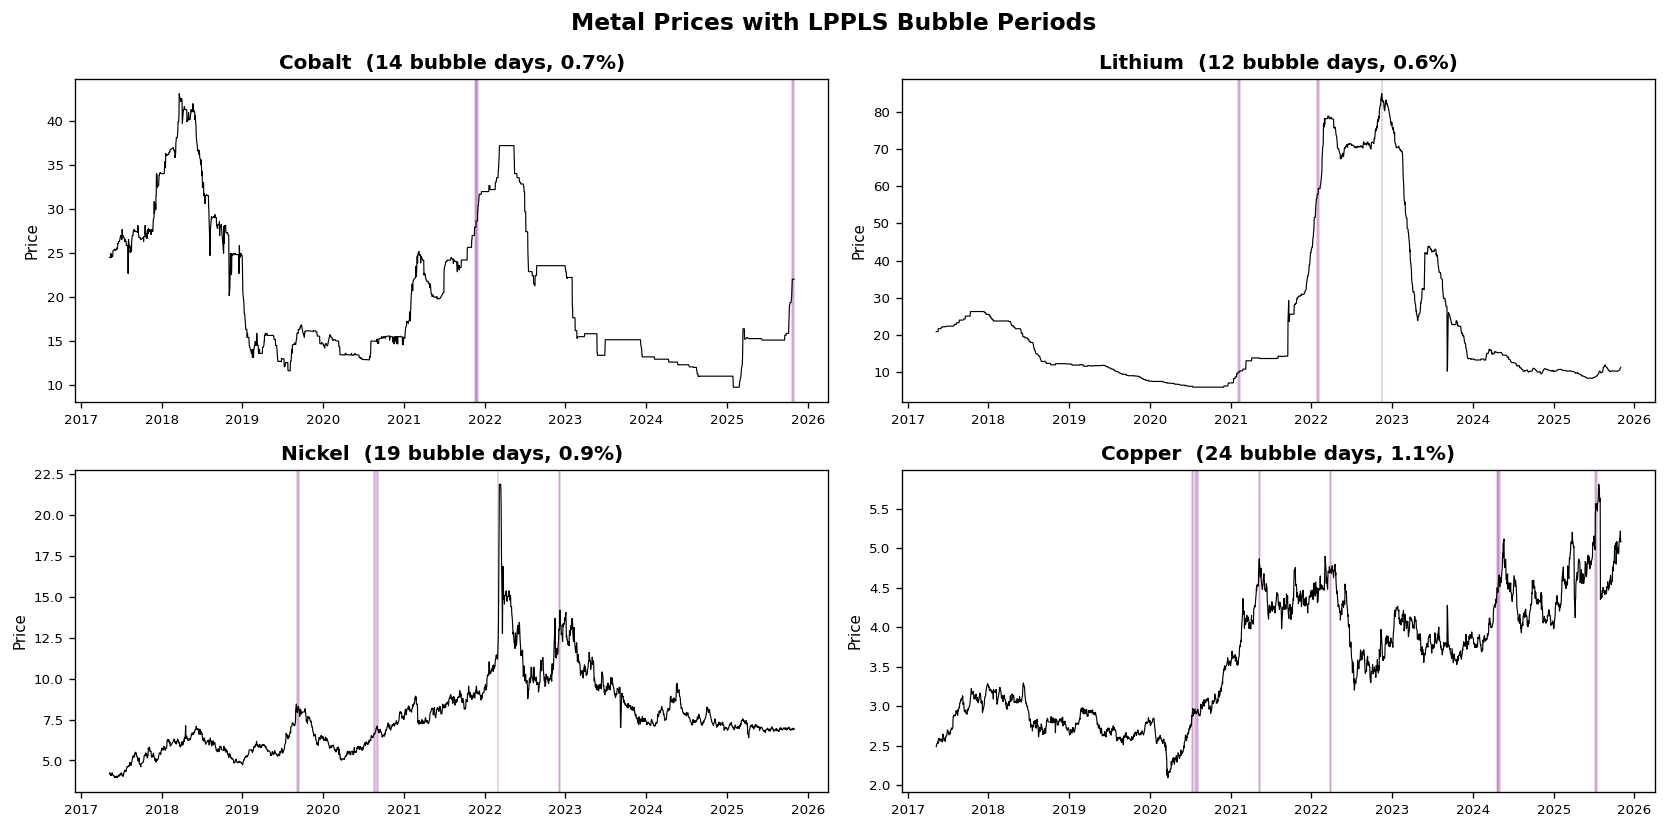

In [3]:
metal_map = {
    'Cobalt':  ('CODALY', 'CODALY_BD'),
    'Lithium': ('LIDALY', 'LIDALY_BD'),
    'Nickel':  ('NIDALY', 'NIDALY_BD'),
    'Copper':  ('CUDALY', 'CUDALY_BD'),
}

fig, axes = plt.subplots(2, 2, figsize=(14, 7))
for idx, (metal, (pcol, dcol)) in enumerate(metal_map.items()):
    ax    = axes.flat[idx]
    dates = df_master['Date']
    ax.plot(dates, df_master[pcol], color='black', lw=0.7)

    bub  = df_master[dcol].values
    in_b = False
    for i in range(len(bub)):
        if bub[i] == 1 and not in_b:
            start = dates.iloc[i]; in_b = True
        elif (bub[i] == 0 or i == len(bub) - 1) and in_b:
            ax.axvspan(start, dates.iloc[i], color='purple', alpha=0.2)
            in_b = False

    n_b = int(df_master[dcol].sum())
    ax.set_title(f'{metal}  ({n_b} bubble days, {100*n_b/len(df_master):.1f}%)',
                 fontsize=12, fontweight='bold')
    ax.tick_params(labelsize=8)
    ax.set_ylabel('Price', fontsize=9)

plt.suptitle('Metal Prices with LPPLS Bubble Periods', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/lppls_bubble_timelines.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()


## 3. Feature Engineering

Identical to `bubble_detection_ml.ipynb`: log-returns + rolling volatility + lagged levels for all series,
peer bubble dummies, all lagged by 1 day.


In [4]:
def prepare_ml_data(target_col, df_master):
    '''Build lagged feature matrix for bubble classification.'''
    target_dummy = target_col + '_BD'
    bubble_cols  = [c for c in df_master.columns if c.endswith('_BD')]
    num_cols     = [c for c in df_master.select_dtypes(include='number').columns
                    if c not in bubble_cols]
    peer_dummies = [c for c in bubble_cols if c != target_dummy]

    df = df_master[['Date'] + num_cols + bubble_cols].copy()
    df = df.sort_values('Date').reset_index(drop=True)

    # Log-returns and 10-day rolling volatility
    for col in num_cols:
        safe = df[col].clip(lower=0.001)
        lr   = np.log(safe).diff()
        df[col + '_Ret'] = lr
        df[col + '_Vol'] = lr.rolling(10).std()

    # Lag ALL features by 1 day (no look-ahead)
    lagged = {}
    for c in [c for c in df.columns if c.endswith('_Ret')]:
        lagged[c + '_Lag1'] = df[c].shift(1)
    for c in [c for c in df.columns if c.endswith('_Vol')]:
        lagged[c + '_Lag1'] = df[c].shift(1)
    for c in num_cols:
        lagged[c + '_Level_Lag1'] = df[c].shift(1)
    for c in peer_dummies:
        lagged[c + '_Lag1'] = df[c].shift(1).fillna(0)

    df_out = pd.DataFrame(lagged, index=df.index)
    df_out['Date']   = df['Date']
    df_out['Target'] = df[target_dummy].astype(int)
    return df_out.dropna().reset_index(drop=True)

# Quick test
df_test = prepare_ml_data('CODALY', df_master)
feats   = [c for c in df_test.columns if c not in ['Date', 'Target']]
print('Features: {} | Rows: {} | Bubble days: {} ({:.1f}%)'.format(
    len(feats), len(df_test), df_test['Target'].sum(),
    100 * df_test['Target'].mean()))


Features: 51 | Rows: 2141 | Bubble days: 14 (0.7%)


## 4. Evaluation Framework

**Expanding-window time-series CV** (5 splits). Same setup as `bubble_detection_ml.ipynb`.

**Guards added for LPPLS sparsity:**
- Folds with fewer than 5 positive training examples are skipped (same threshold as original)
- If *all* folds are skipped, the metal is excluded from results with a warning
- `compute_metrics` handles the case where the test set contains only one class


In [5]:
def compute_metrics(y_true, y_prob, threshold=0.5):
    '''Compute classification metrics. Returns neutral defaults if no valid data.'''
    if len(y_true) == 0 or len(np.unique(y_true)) < 2:
        return {'Bal. Accuracy': 0.5, 'Sensitivity': 0.0, 'Specificity': 0.0,
                'Precision': 0.0, 'AUC': 0.5, 'Bubbles': '0/0'}
    y_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    sens = tp / (tp + fn) if (tp + fn) > 0 else 0
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    auc  = roc_auc_score(y_true, y_prob)
    return {
        'Bal. Accuracy': round((sens + spec) / 2, 3),
        'Sensitivity':   round(sens, 3),
        'Specificity':   round(spec, 3),
        'Precision':     round(prec, 3),
        'AUC':           round(auc, 3),
        'Bubbles':       '{}/{}'.format(tp, tp + fn)
    }


def run_timeseries_cv(X, y, model_fn, n_splits=5, scale=False):
    '''Expanding-window time-series CV. Returns empty arrays if no fold is valid.'''
    tscv = TimeSeriesSplit(n_splits=n_splits)
    all_preds, all_true = [], []

    for train_idx, test_idx in tscv.split(X):
        X_tr, X_te = X[train_idx], X[test_idx]
        y_tr, y_te = y[train_idx], y[test_idx]
        if y_tr.sum() < 5:   # too few positive examples to train on
            continue
        if scale:
            sc   = StandardScaler()
            X_tr = sc.fit_transform(X_tr)
            X_te = sc.transform(X_te)
        model = model_fn()
        model.fit(X_tr, y_tr)
        all_preds.append(model.predict_proba(X_te)[:, 1])
        all_true.append(y_te)

    if not all_preds:                       # no valid fold at all
        return np.array([]), np.array([])
    return np.concatenate(all_preds), np.concatenate(all_true)


# Storage
cv_preds      = {}   # (metal, model_name) -> (y_true, y_prob)
metal_configs = {'Cobalt': 'CODALY', 'Lithium': 'LIDALY',
                 'Nickel': 'NIDALY', 'Copper':  'CUDALY'}
print('CV framework ready.')


CV framework ready.


## 5. LASSO (Linear Benchmark) + Hyperparameter Tuning

$$\min_{\beta} \; -\frac{1}{n}\sum_{i=1}^n \big[ y_i \log \hat{p}_i + (1-y_i)\log(1-\hat{p}_i) \big] + \frac{1}{C}\|\beta\|_1$$

**Tuned:** $C \in \{0.001, 0.01, 0.1, 1, 10\}$ via time-series CV, optimizing AUC.


In [6]:
results_lasso    = {}
lasso_models     = {}
lasso_best_params = {}

C_grid = [0.001, 0.01, 0.1, 1.0, 10.0]

print('LASSO — Tuning C via Time-Series CV')
print('=' * 55)

for metal, col in metal_configs.items():
    df_ml = prepare_ml_data(col, df_master)
    feats = [c for c in df_ml.columns if c not in ['Date', 'Target']]
    X, y  = df_ml[feats].values, df_ml['Target'].values

    if y.sum() < 10:
        print(f'  {metal}: skipped — only {int(y.sum())} bubble days total')
        continue

    # Grid search over C
    best_auc, best_C = -1, 1.0
    for C_val in C_grid:
        def make_lasso_c(c=C_val):
            return LogisticRegression(penalty='l1', solver='saga', C=c,
                                      class_weight='balanced', max_iter=10000, random_state=42)
        try:
            preds_c, true_c = run_timeseries_cv(X, y, make_lasso_c, n_splits=5, scale=True)
            if len(true_c) == 0 or len(np.unique(true_c)) < 2:
                continue
            auc_c = roc_auc_score(true_c, preds_c)
            if auc_c > best_auc:
                best_auc, best_C = auc_c, C_val
        except Exception:
            continue

    # Final run with best C
    def make_lasso_best(c=best_C):
        return LogisticRegression(penalty='l1', solver='saga', C=c,
                                  class_weight='balanced', max_iter=10000, random_state=42)

    preds, true = run_timeseries_cv(X, y, make_lasso_best, n_splits=5, scale=True)

    if len(preds) == 0 or len(np.unique(true)) < 2:
        print(f'  {metal}: no valid CV fold produced (all folds had <5 training bubbles)')
        continue

    metrics = compute_metrics(true, preds)
    results_lasso[metal]     = metrics
    lasso_best_params[metal] = {'C': best_C}
    cv_preds[(metal, 'LASSO')] = (true, preds)

    # Full model for coefficient analysis
    sc         = StandardScaler()
    full_model = make_lasso_best()
    full_model.fit(sc.fit_transform(X), y)
    lasso_models[metal] = {'model': full_model, 'features': feats, 'scaler': sc}

    n_nz = int(np.sum(full_model.coef_[0] != 0))
    print('  {}: AUC={:.3f}  Bal.Acc={:.3f}  Bubbles={}  (C={}, non-zero: {})'.format(
        metal, metrics['AUC'], metrics['Bal. Accuracy'], metrics['Bubbles'], best_C, n_nz))


LASSO — Tuning C via Time-Series CV
  Cobalt: AUC=0.567  Bal.Acc=0.452  Bubbles=0/5  (C=0.1, non-zero: 13)
  Lithium: no valid CV fold produced (all folds had <5 training bubbles)
  Nickel: AUC=0.834  Bal.Acc=0.834  Bubbles=3/3  (C=0.001, non-zero: 0)
  Copper: AUC=0.850  Bal.Acc=0.790  Bubbles=9/13  (C=10.0, non-zero: 49)


## 6. Random Forest + Hyperparameter Tuning

$$\hat{p}(x) = \frac{1}{B}\sum_{b=1}^{B} T_b(x)$$

**Tuned via randomized search** (20 draws):
- `max_depth` ∈ {5, 10, 15, 20, None}
- `min_samples_leaf` ∈ {1, 5, 10, 25}
- `max_features` ∈ {`'sqrt'`, `'log2'`, 0.3}


In [7]:
results_rf     = {}
rf_models      = {}
rf_best_params = {}

rf_param_grid = {
    'max_depth':        [5, 10, 15, 20, None],
    'min_samples_leaf': [1, 5, 10, 25],
    'max_features':     ['sqrt', 'log2', 0.3],
}
all_combos   = [dict(zip(rf_param_grid.keys(), v)) for v in product(*rf_param_grid.values())]
random.seed(42)
rf_candidates = random.sample(all_combos, min(20, len(all_combos)))

print('Random Forest — Randomized Search ({} configs)'.format(len(rf_candidates)))
print('=' * 55)

for metal, col in metal_configs.items():
    df_ml = prepare_ml_data(col, df_master)
    feats = [c for c in df_ml.columns if c not in ['Date', 'Target']]
    X, y  = df_ml[feats].values, df_ml['Target'].values

    if y.sum() < 10:
        print(f'  {metal}: skipped — only {int(y.sum())} bubble days total')
        continue

    best_auc, best_params = -1, {}
    for params in rf_candidates:
        def make_rf_p(p=params):
            return RandomForestClassifier(n_estimators=500, class_weight='balanced',
                                          random_state=42, n_jobs=-1, **p)
        try:
            preds_p, true_p = run_timeseries_cv(X, y, make_rf_p, n_splits=5)
            if len(true_p) == 0 or len(np.unique(true_p)) < 2:
                continue
            auc_p = roc_auc_score(true_p, preds_p)
            if auc_p > best_auc:
                best_auc, best_params = auc_p, params
        except Exception:
            continue

    def make_rf_best(p=best_params):
        return RandomForestClassifier(n_estimators=500, class_weight='balanced',
                                      random_state=42, n_jobs=-1, **p)

    preds, true = run_timeseries_cv(X, y, make_rf_best, n_splits=5)

    if len(preds) == 0 or len(np.unique(true)) < 2:
        print(f'  {metal}: no valid CV fold produced')
        continue

    metrics = compute_metrics(true, preds)
    results_rf[metal]     = metrics
    rf_best_params[metal] = best_params
    cv_preds[(metal, 'Random Forest')] = (true, preds)

    full_model = make_rf_best()
    full_model.fit(X, y)
    rf_models[metal] = {'model': full_model, 'features': feats, 'X': X, 'y': y}

    print('  {}: AUC={:.3f}  Bal.Acc={:.3f}  Bubbles={}  {}'.format(
        metal, metrics['AUC'], metrics['Bal. Accuracy'], metrics['Bubbles'],
        {k: v for k, v in best_params.items()}))


Random Forest — Randomized Search (20 configs)
  Cobalt: AUC=0.791  Bal.Acc=0.500  Bubbles=0/5  {'max_depth': 10, 'min_samples_leaf': 5, 'max_features': 'sqrt'}
  Lithium: no valid CV fold produced
  Nickel: AUC=0.784  Bal.Acc=0.500  Bubbles=0/3  {'max_depth': 20, 'min_samples_leaf': 25, 'max_features': 0.3}
  Copper: AUC=0.790  Bal.Acc=0.500  Bubbles=0/13  {'max_depth': 10, 'min_samples_leaf': 5, 'max_features': 0.3}


## 7. LightGBM + Hyperparameter Tuning

$$F_t(x) = F_{t-1}(x) + \eta \cdot f_t(x)$$

**Tuned via randomized search** (30 draws) with early stopping per fold:
- `num_leaves` ∈ {15, 31, 63}, `max_depth` ∈ {-1, 5, 10}, `learning_rate` ∈ {0.01, 0.05, 0.1}
- `lambda_l1`, `lambda_l2` ∈ {0, 0.1, 1.0, 5.0}, `min_data_in_leaf` ∈ {5, 20, 50}


In [8]:
results_lgbm     = {}
lgbm_models      = {}
lgbm_best_params = {}

lgb_base = {
    'objective': 'binary', 'metric': 'auc',
    'is_unbalance': True,
    'feature_fraction': 0.8, 'bagging_fraction': 0.8, 'bagging_freq': 5,
    'verbosity': -1, 'seed': 42,
}
lgb_tune_grid = {
    'num_leaves':       [15, 31, 63],
    'max_depth':        [-1, 5, 10],
    'learning_rate':    [0.01, 0.05, 0.1],
    'lambda_l1':        [0, 0.1, 1.0, 5.0],
    'lambda_l2':        [0, 0.1, 1.0, 5.0],
    'min_data_in_leaf': [5, 20, 50],
}
all_lgb_combos = [dict(zip(lgb_tune_grid.keys(), v)) for v in product(*lgb_tune_grid.values())]
random.seed(42)
lgb_candidates = random.sample(all_lgb_combos, min(30, len(all_lgb_combos)))


def run_lgbm_cv(X, y, params, n_splits=5):
    '''LightGBM time-series CV with early stopping. Returns empty arrays if no valid fold.'''
    tscv = TimeSeriesSplit(n_splits=n_splits)
    all_preds, all_true, iters = [], [], []

    for train_idx, test_idx in tscv.split(X):
        X_tr, X_te = X[train_idx], X[test_idx]
        y_tr, y_te = y[train_idx], y[test_idx]
        if y_tr.sum() < 5:
            continue

        val_n         = max(int(len(X_tr) * 0.2), 50)
        X_val, y_val  = X_tr[-val_n:], y_tr[-val_n:]
        X_tr_i, y_tr_i = X_tr[:-val_n], y_tr[:-val_n]

        if y_tr_i.sum() < 3:   # inner train set too sparse for valid gradient
            continue

        d_train = lgb.Dataset(X_tr_i, y_tr_i)
        d_val   = lgb.Dataset(X_val,  y_val, reference=d_train)
        bst = lgb.train(
            params, d_train, num_boost_round=500, valid_sets=[d_val],
            callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)])
        all_preds.append(bst.predict(X_te))
        all_true.append(y_te)
        iters.append(bst.best_iteration)

    if not all_preds:
        return np.array([]), np.array([]), []
    return np.concatenate(all_preds), np.concatenate(all_true), iters


print('LightGBM — Randomized Search ({} configs)'.format(len(lgb_candidates)))
print('=' * 55)

for metal, col in metal_configs.items():
    df_ml = prepare_ml_data(col, df_master)
    feats = [c for c in df_ml.columns if c not in ['Date', 'Target']]
    X, y  = df_ml[feats].values, df_ml['Target'].values

    if y.sum() < 10:
        print(f'  {metal}: skipped — only {int(y.sum())} bubble days total')
        continue

    best_auc, best_hp = -1, {}
    for hp in lgb_candidates:
        params = {**lgb_base, **hp}
        try:
            preds_hp, true_hp, _ = run_lgbm_cv(X, y, params, n_splits=5)
            if len(true_hp) == 0 or len(np.unique(true_hp)) < 2:
                continue
            auc_hp = roc_auc_score(true_hp, preds_hp)
            if auc_hp > best_auc:
                best_auc, best_hp = auc_hp, hp
        except Exception:
            continue

    best_params = {**lgb_base, **best_hp}
    preds_arr, true_arr, best_iters = run_lgbm_cv(X, y, best_params, n_splits=5)

    if len(preds_arr) == 0 or len(np.unique(true_arr)) < 2:
        print(f'  {metal}: no valid CV fold produced')
        continue

    metrics = compute_metrics(true_arr, preds_arr)
    results_lgbm[metal]     = metrics
    lgbm_best_params[metal] = best_hp
    cv_preds[(metal, 'LightGBM')] = (true_arr, preds_arr)

    avg_iter = int(np.mean(best_iters)) if best_iters else 0
    d_full   = lgb.Dataset(X, y)
    bst_full = lgb.train(best_params, d_full,
                         num_boost_round=max(avg_iter, 10))
    lgbm_models[metal] = {'model': bst_full, 'features': feats, 'X': X, 'y': y}

    print('  {}: AUC={:.3f}  Bal.Acc={:.3f}  Bubbles={}  (iters: {})'.format(
        metal, metrics['AUC'], metrics['Bal. Accuracy'], metrics['Bubbles'], avg_iter))
    print('        best: lr={}, leaves={}, depth={}, l1={}, l2={}, min_leaf={}'.format(
        best_hp.get('learning_rate'), best_hp.get('num_leaves'), best_hp.get('max_depth'),
        best_hp.get('lambda_l1'),     best_hp.get('lambda_l2'), best_hp.get('min_data_in_leaf')))


LightGBM — Randomized Search (30 configs)
  Cobalt: AUC=0.752  Bal.Acc=0.640  Bubbles=5/5  (iters: 1)
        best: lr=0.05, leaves=15, depth=5, l1=5.0, l2=0, min_leaf=5
  Lithium: no valid CV fold produced
  Nickel: AUC=0.798  Bal.Acc=0.431  Bubbles=0/3  (iters: 4)
        best: lr=0.1, leaves=31, depth=5, l1=1.0, l2=0, min_leaf=5
  Copper: AUC=0.846  Bal.Acc=0.563  Bubbles=2/13  (iters: 46)
        best: lr=0.05, leaves=63, depth=10, l1=1.0, l2=1.0, min_leaf=50


## 8. Results Comparison


 Metal         Model  Bal. Accuracy  Sensitivity  Specificity  Precision   AUC Bubbles
Cobalt         LASSO          0.452        0.000        0.904      0.000 0.567     0/5
Cobalt Random Forest          0.500        0.000        1.000      0.000 0.791     0/5
Cobalt      LightGBM          0.640        1.000        0.280      0.010 0.752     5/5
Nickel         LASSO          0.834        1.000        0.669      0.008 0.834     3/3
Nickel Random Forest          0.500        0.000        1.000      0.000 0.784     0/3
Nickel      LightGBM          0.431        0.000        0.862      0.000 0.798     0/3
Copper         LASSO          0.790        0.692        0.887      0.070 0.850    9/13
Copper Random Forest          0.500        0.000        1.000      0.000 0.790    0/13
Copper      LightGBM          0.563        0.154        0.972      0.062 0.846    2/13



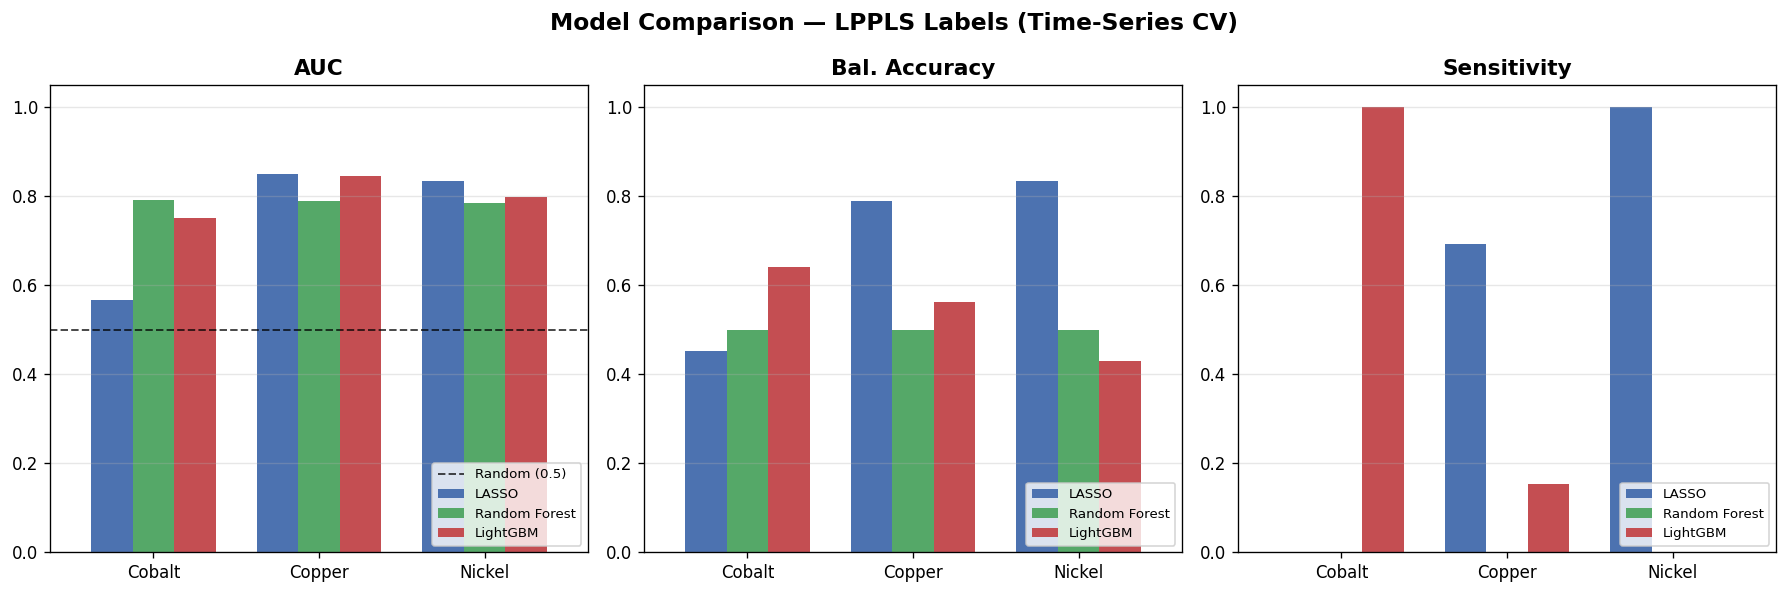

In [9]:
rows = []
for metal in metal_configs:
    for mname, res_dict in [('LASSO', results_lasso),
                             ('Random Forest', results_rf),
                             ('LightGBM', results_lgbm)]:
        if metal in res_dict:
            row = {'Metal': metal, 'Model': mname}
            row.update(res_dict[metal])
            rows.append(row)

if not rows:
    print('No results to display — all metals were skipped due to insufficient bubble days.')
else:
    df_results   = pd.DataFrame(rows)
    display_cols = ['Metal', 'Model', 'Bal. Accuracy', 'Sensitivity',
                    'Specificity', 'Precision', 'AUC', 'Bubbles']
    print(df_results[display_cols].to_string(index=False))
    print()

    models_present = [m for m in ['LASSO', 'Random Forest', 'LightGBM']
                      if m in df_results['Model'].unique()]

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    colors = {'LASSO': '#4C72B0', 'Random Forest': '#55A868', 'LightGBM': '#C44E52'}

    for i, metric in enumerate(['AUC', 'Bal. Accuracy', 'Sensitivity']):
        ax    = axes[i]
        pivot = df_results.pivot(index='Metal', columns='Model', values=metric)
        pivot = pivot[[m for m in ['LASSO', 'Random Forest', 'LightGBM']
                       if m in pivot.columns]]
        pivot.plot(kind='bar', ax=ax, rot=0,
                   color=[colors[c] for c in pivot.columns], width=0.75)
        ax.set_title(metric, fontsize=13, fontweight='bold')
        ax.set_xlabel('')
        ax.set_ylim(0, 1.05)
        ax.legend(fontsize=8, loc='lower right')
        ax.grid(axis='y', alpha=0.3)
        if metric == 'AUC':
            ax.axhline(0.5, color='black', lw=1.2, ls='--', alpha=0.7, label='Random (0.5)')
            ax.legend(fontsize=8, loc='lower right')

    plt.suptitle('Model Comparison — LPPLS Labels (Time-Series CV)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('outputs/lppls_model_comparison.png', dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()


In [10]:
# Best hyperparameters found per model
print('Best Hyperparameters')
print('=' * 55)
for metal in metal_configs:
    lines = []
    if metal in lasso_best_params:
        lines.append(f'  LASSO:    C={lasso_best_params[metal]["C"]}')
    if metal in rf_best_params:
        lines.append(f'  RF:       {rf_best_params[metal]}')
    if metal in lgbm_best_params:
        lines.append(f'  LightGBM: {lgbm_best_params[metal]}')
    if lines:
        print(f'\n{metal}:')
        for l in lines:
            print(l)
    else:
        print(f'\n{metal}: no results (insufficient bubble days)')


Best Hyperparameters

Cobalt:
  LASSO:    C=0.1
  RF:       {'max_depth': 10, 'min_samples_leaf': 5, 'max_features': 'sqrt'}
  LightGBM: {'num_leaves': 15, 'max_depth': 5, 'learning_rate': 0.05, 'lambda_l1': 5.0, 'lambda_l2': 0, 'min_data_in_leaf': 5}

Lithium: no results (insufficient bubble days)

Nickel:
  LASSO:    C=0.001
  RF:       {'max_depth': 20, 'min_samples_leaf': 25, 'max_features': 0.3}
  LightGBM: {'num_leaves': 31, 'max_depth': 5, 'learning_rate': 0.1, 'lambda_l1': 1.0, 'lambda_l2': 0, 'min_data_in_leaf': 5}

Copper:
  LASSO:    C=10.0
  RF:       {'max_depth': 10, 'min_samples_leaf': 5, 'max_features': 0.3}
  LightGBM: {'num_leaves': 63, 'max_depth': 10, 'learning_rate': 0.05, 'lambda_l1': 1.0, 'lambda_l2': 1.0, 'min_data_in_leaf': 50}


## 9. ROC Curves


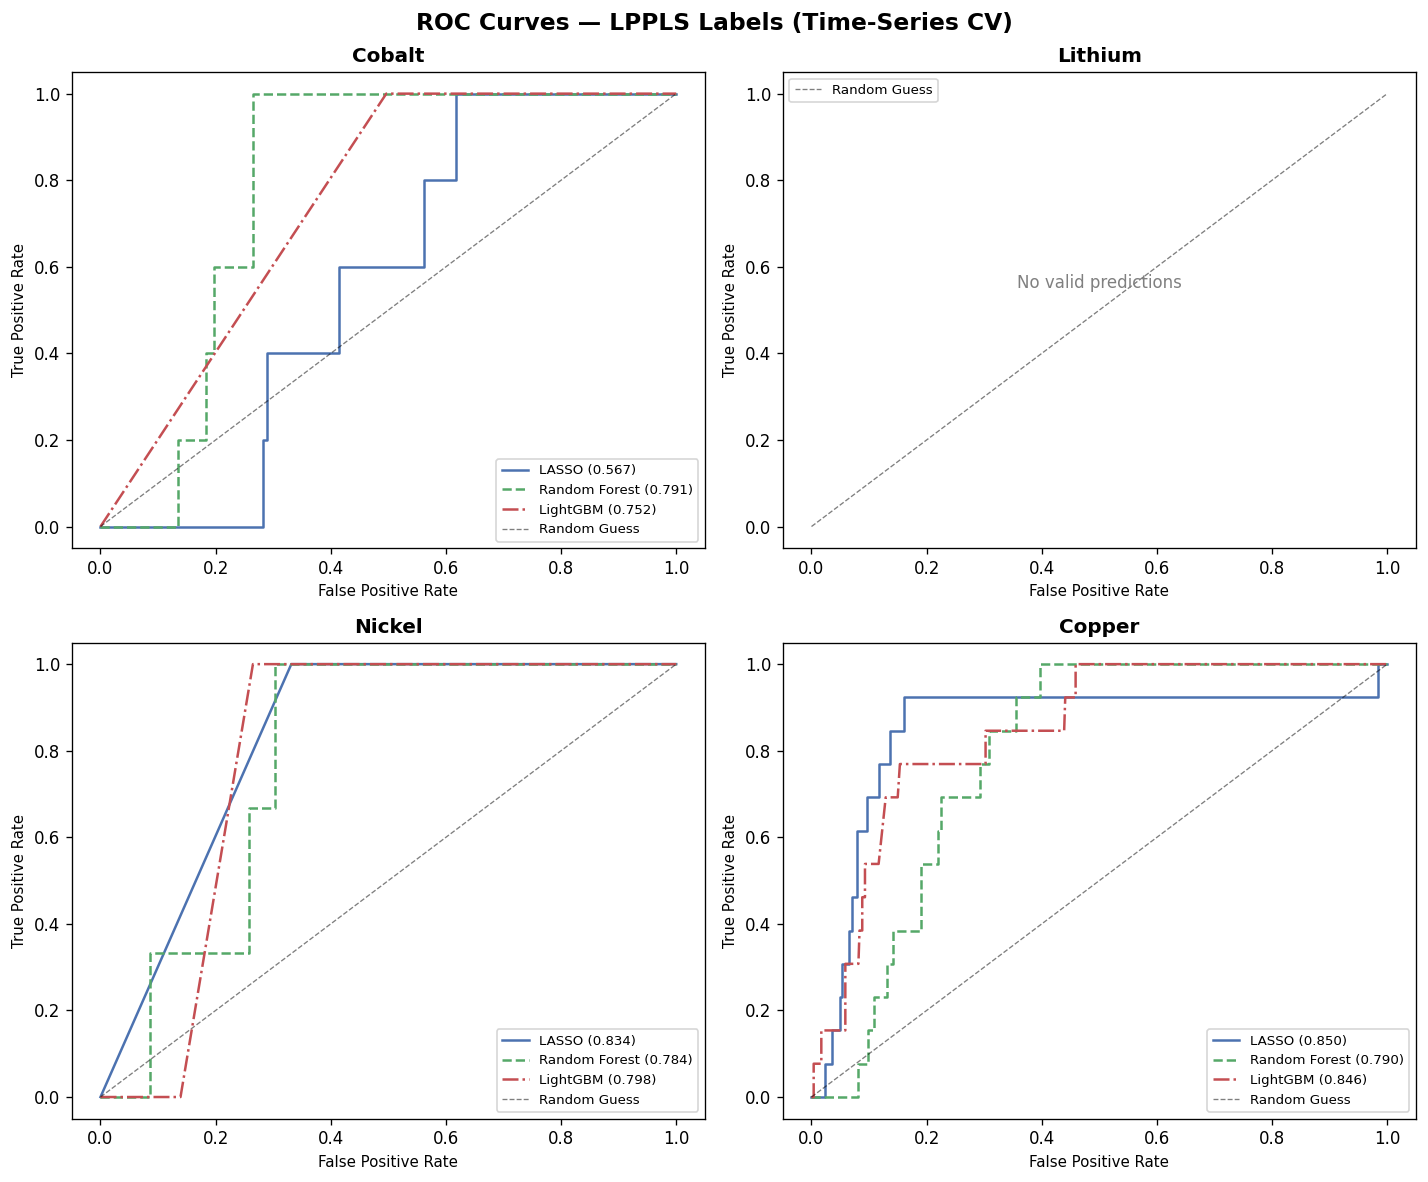

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
colors = {'LASSO': '#4C72B0', 'Random Forest': '#55A868', 'LightGBM': '#C44E52'}
styles = {'LASSO': '-',       'Random Forest': '--',     'LightGBM': '-.'}

for idx, metal in enumerate(metal_configs):
    ax = axes.flat[idx]
    plotted = False
    for mname in ['LASSO', 'Random Forest', 'LightGBM']:
        key = (metal, mname)
        if key not in cv_preds:
            continue
        yt, yp = cv_preds[key]
        # Guard: roc_curve requires both classes present in test set
        if len(np.unique(yt)) < 2:
            ax.text(0.5, 0.4, f'{mname}: only 1 class in test folds',
                    ha='center', fontsize=7, color=colors[mname])
            continue
        try:
            fpr, tpr, _ = roc_curve(yt, yp)
            auc_val      = roc_auc_score(yt, yp)
            ax.plot(fpr, tpr, color=colors[mname], ls=styles[mname], lw=1.5,
                    label=f'{mname} ({auc_val:.3f})')
            plotted = True
        except ValueError as e:
            ax.text(0.5, 0.5, f'{mname}: {e}', ha='center', fontsize=7)

    ax.plot([0, 1], [0, 1], 'k--', lw=0.8, alpha=0.5, label='Random Guess')
    if not plotted:
        ax.text(0.5, 0.55, 'No valid predictions', ha='center', fontsize=10,
                color='grey')
    ax.set_title(metal, fontsize=12, fontweight='bold')
    ax.legend(fontsize=8)
    ax.set_xlabel('False Positive Rate', fontsize=9)
    ax.set_ylabel('True Positive Rate', fontsize=9)

plt.suptitle('ROC Curves — LPPLS Labels (Time-Series CV)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/lppls_roc_curves.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()


## 10. Feature Importance

- **LightGBM:** SHAP values (TreeSHAP)
- **LASSO:** Non-zero standardized coefficients
- **Random Forest:** Gini importance


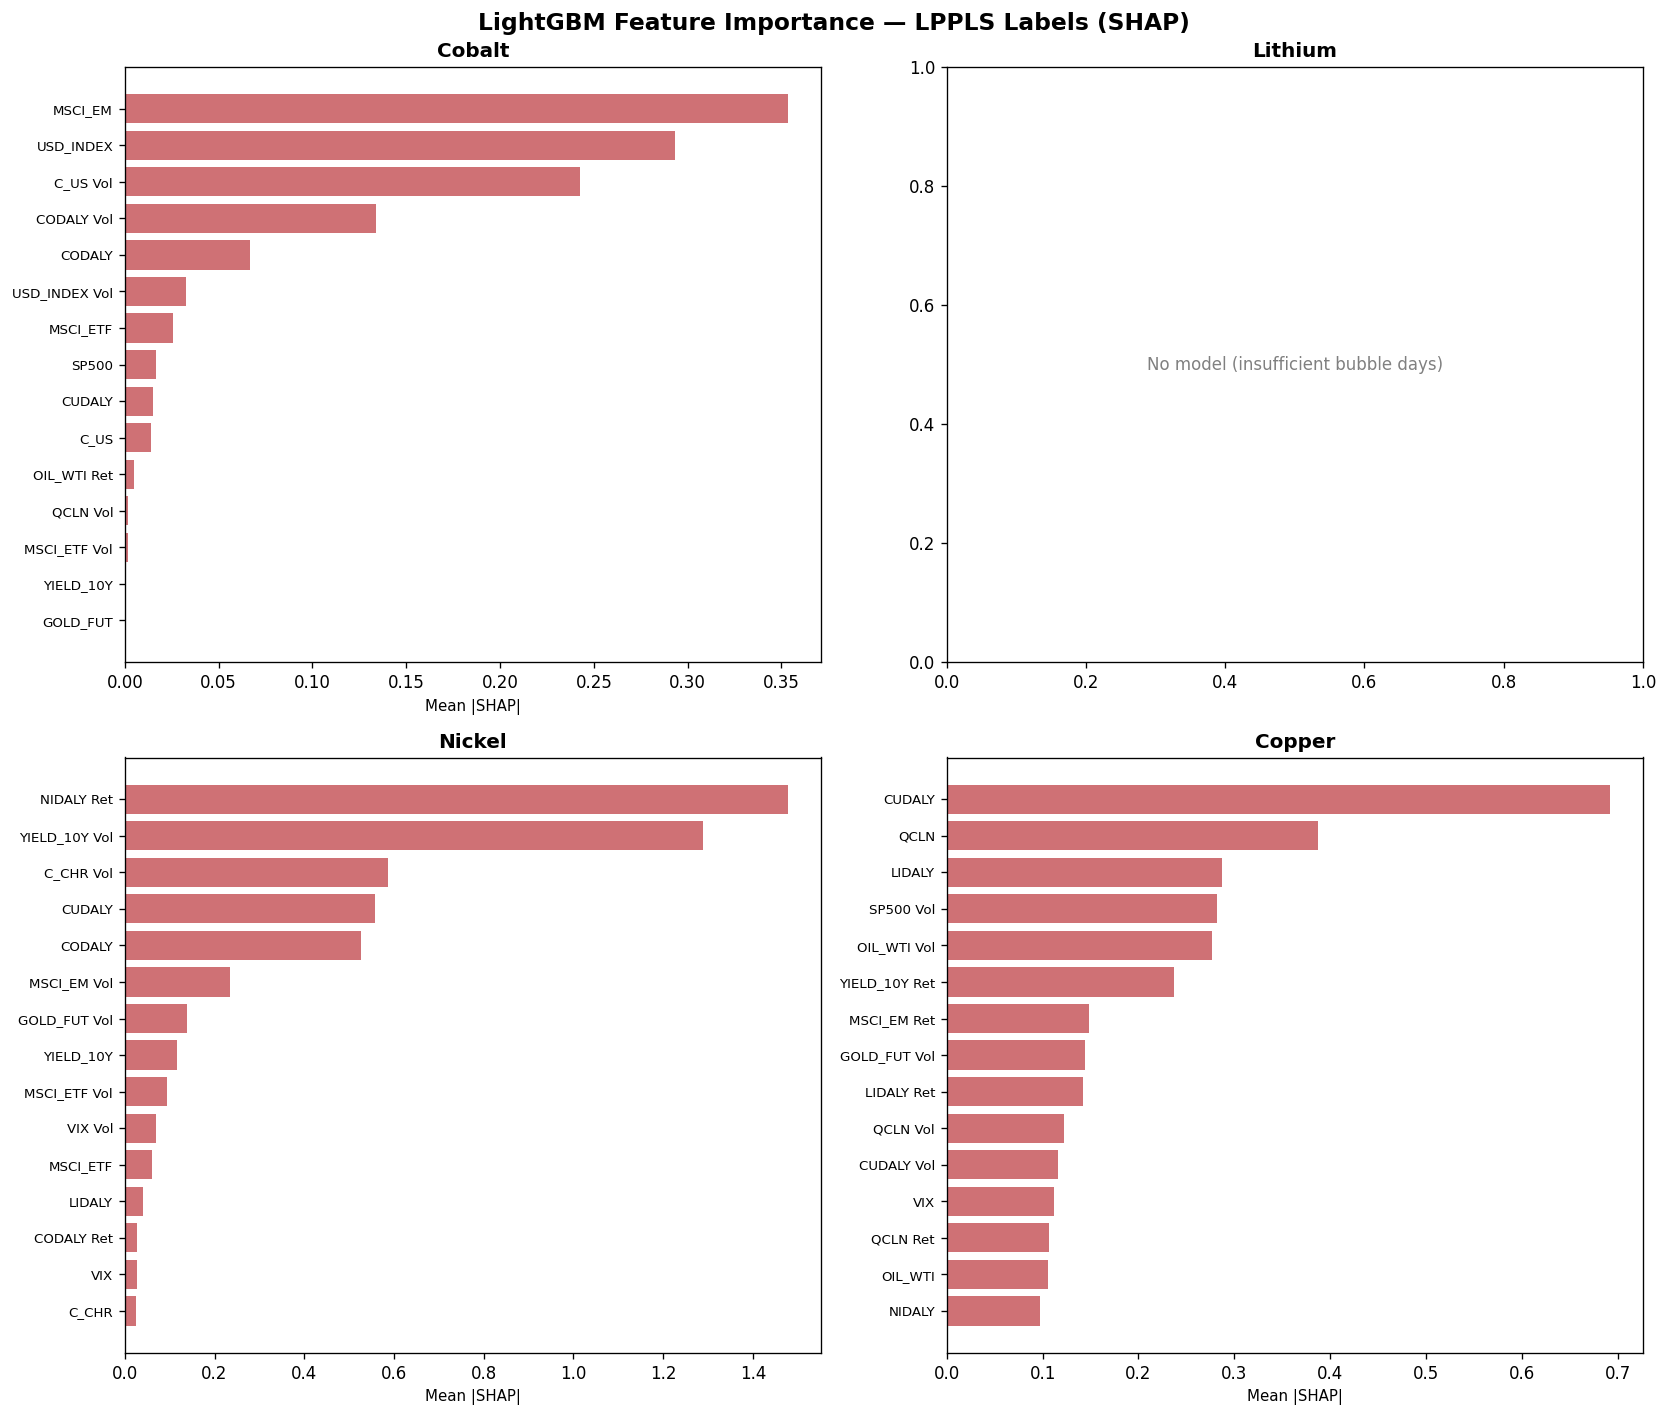

In [12]:
def clean_name(s):
    return (s.replace('_Lag1', '').replace('_Level', '')
             .replace('_Ret', ' Ret').replace('_Vol', ' Vol')
             .replace('_BD', ' Bubble'))

# --- LightGBM SHAP ---
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
for idx, (metal, col) in enumerate(metal_configs.items()):
    ax = axes.flat[idx]
    if metal not in lgbm_models:
        ax.text(0.5, 0.5, 'No model (insufficient bubble days)',
                ha='center', va='center', transform=ax.transAxes, fontsize=10, color='grey')
        ax.set_title(metal, fontsize=12, fontweight='bold')
        continue
    info      = lgbm_models[metal]
    explainer = shap.TreeExplainer(info['model'])
    np.random.seed(42)
    sample_idx = np.random.choice(len(info['X']), min(500, len(info['X'])), replace=False)
    sv = explainer.shap_values(info['X'][sample_idx])
    if isinstance(sv, list):
        sv = sv[1]

    mean_abs = np.mean(np.abs(sv), axis=0)
    top_k    = 15
    top_idx  = np.argsort(mean_abs)[-top_k:]
    names    = [clean_name(info['features'][i]) for i in top_idx]

    ax.barh(range(top_k), mean_abs[top_idx], color='#C44E52', alpha=0.8)
    ax.set_yticks(range(top_k))
    ax.set_yticklabels(names, fontsize=8)
    ax.set_title(metal, fontsize=12, fontweight='bold')
    ax.set_xlabel('Mean |SHAP|', fontsize=9)

plt.suptitle('LightGBM Feature Importance — LPPLS Labels (SHAP)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/lppls_shap_lgbm.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()


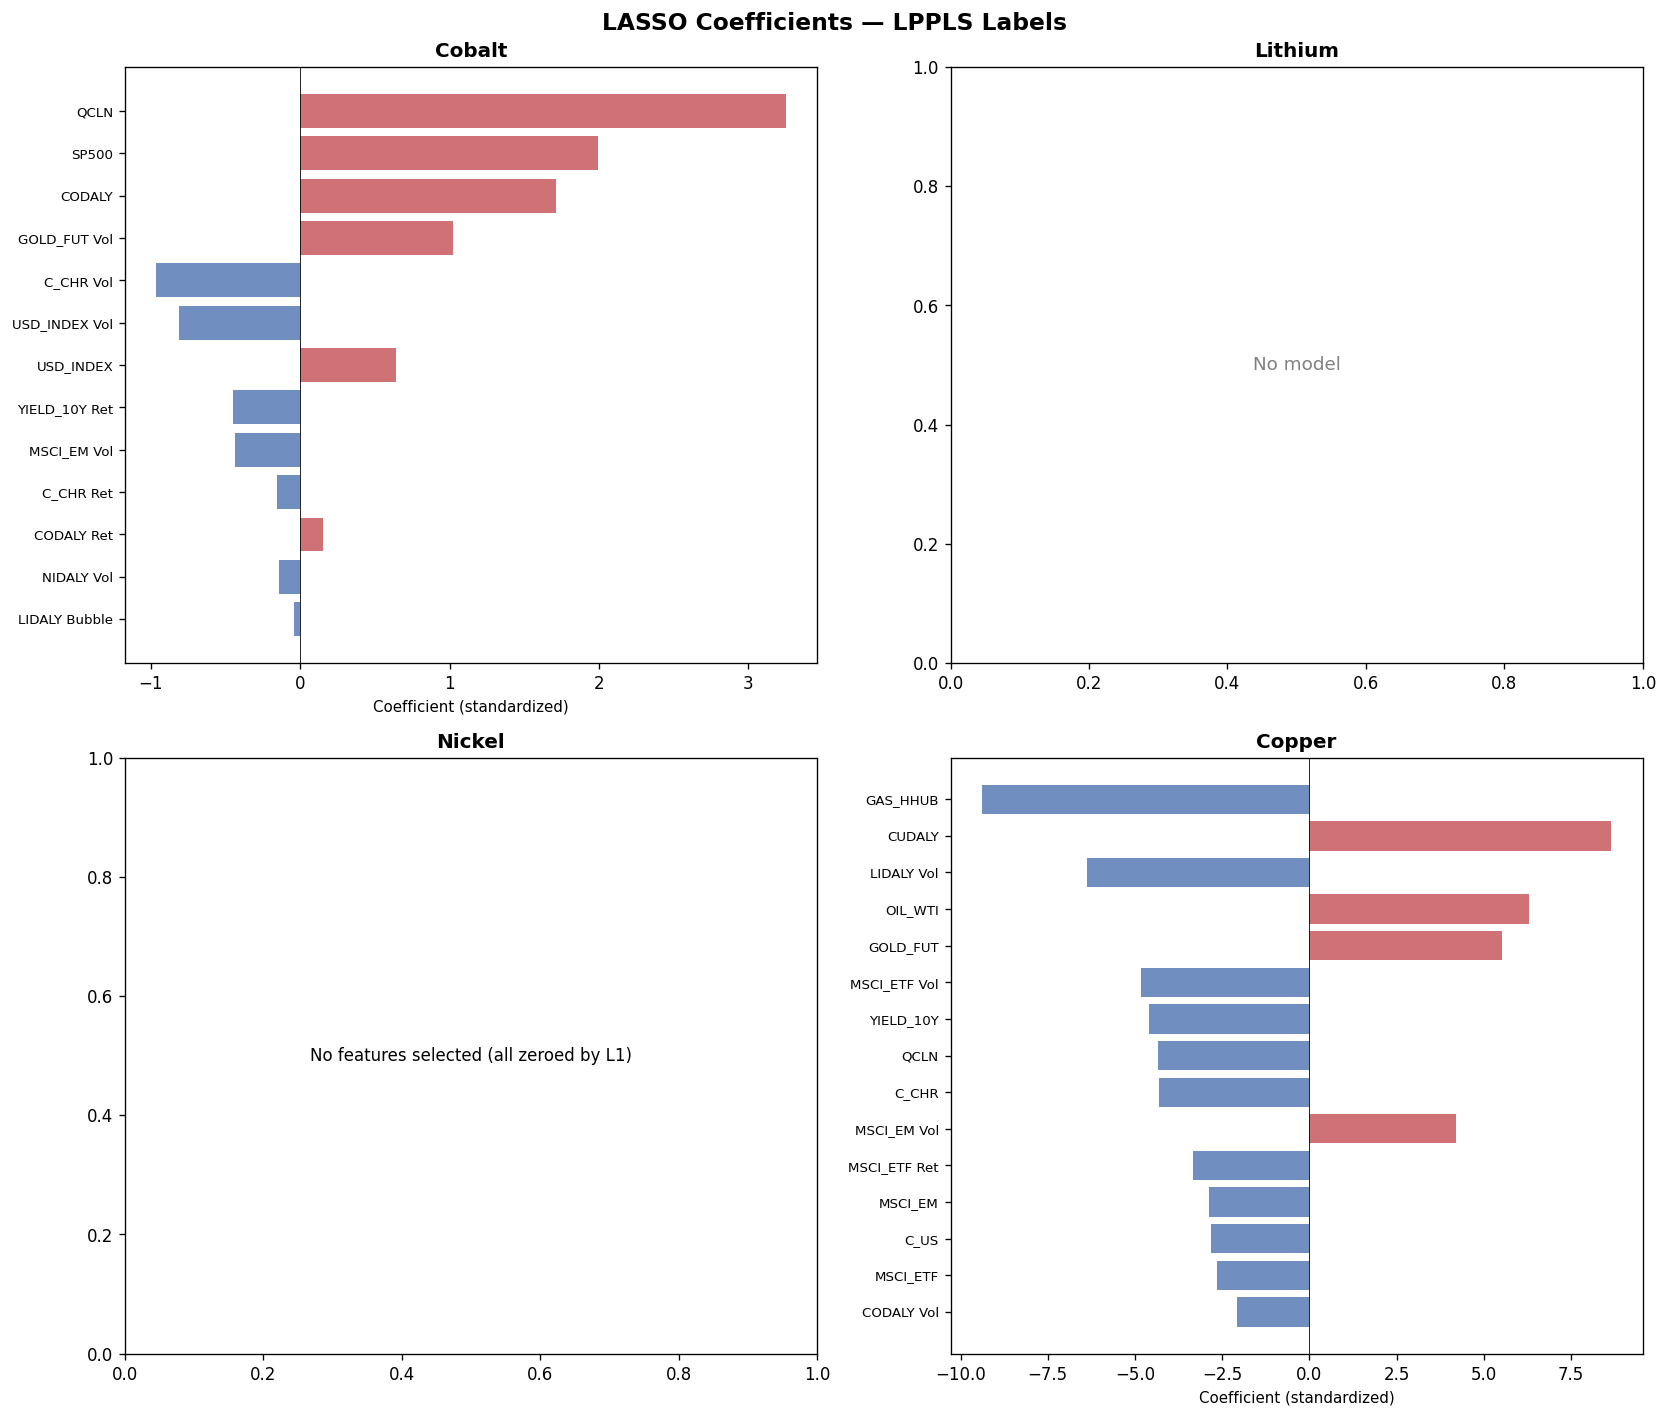

In [13]:
# --- LASSO Coefficients ---
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
for idx, (metal, col) in enumerate(metal_configs.items()):
    ax = axes.flat[idx]
    if metal not in lasso_models:
        ax.text(0.5, 0.5, 'No model', ha='center', va='center',
                transform=ax.transAxes, fontsize=11, color='grey')
        ax.set_title(metal, fontsize=12, fontweight='bold')
        continue
    info    = lasso_models[metal]
    coefs   = info['model'].coef_[0]
    feats   = info['features']
    nz_mask = coefs != 0

    if nz_mask.sum() == 0:
        ax.text(0.5, 0.5, 'No features selected (all zeroed by L1)',
                ha='center', va='center', transform=ax.transAxes, fontsize=10)
        ax.set_title(metal, fontsize=12, fontweight='bold')
        continue

    nz_coefs = coefs[nz_mask]
    nz_names = [clean_name(feats[i]) for i in range(len(feats)) if nz_mask[i]]
    top_k    = min(15, len(nz_coefs))
    order    = np.argsort(np.abs(nz_coefs))[-top_k:]
    bar_cols = ['#C44E52' if nz_coefs[j] > 0 else '#4C72B0' for j in order]

    ax.barh(range(top_k), nz_coefs[order], color=bar_cols, alpha=0.8)
    ax.set_yticks(range(top_k))
    ax.set_yticklabels([nz_names[j] for j in order], fontsize=8)
    ax.set_title(metal, fontsize=12, fontweight='bold')
    ax.set_xlabel('Coefficient (standardized)', fontsize=9)
    ax.axvline(0, color='black', lw=0.5)

plt.suptitle('LASSO Coefficients — LPPLS Labels', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/lppls_lasso_coefficients.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()


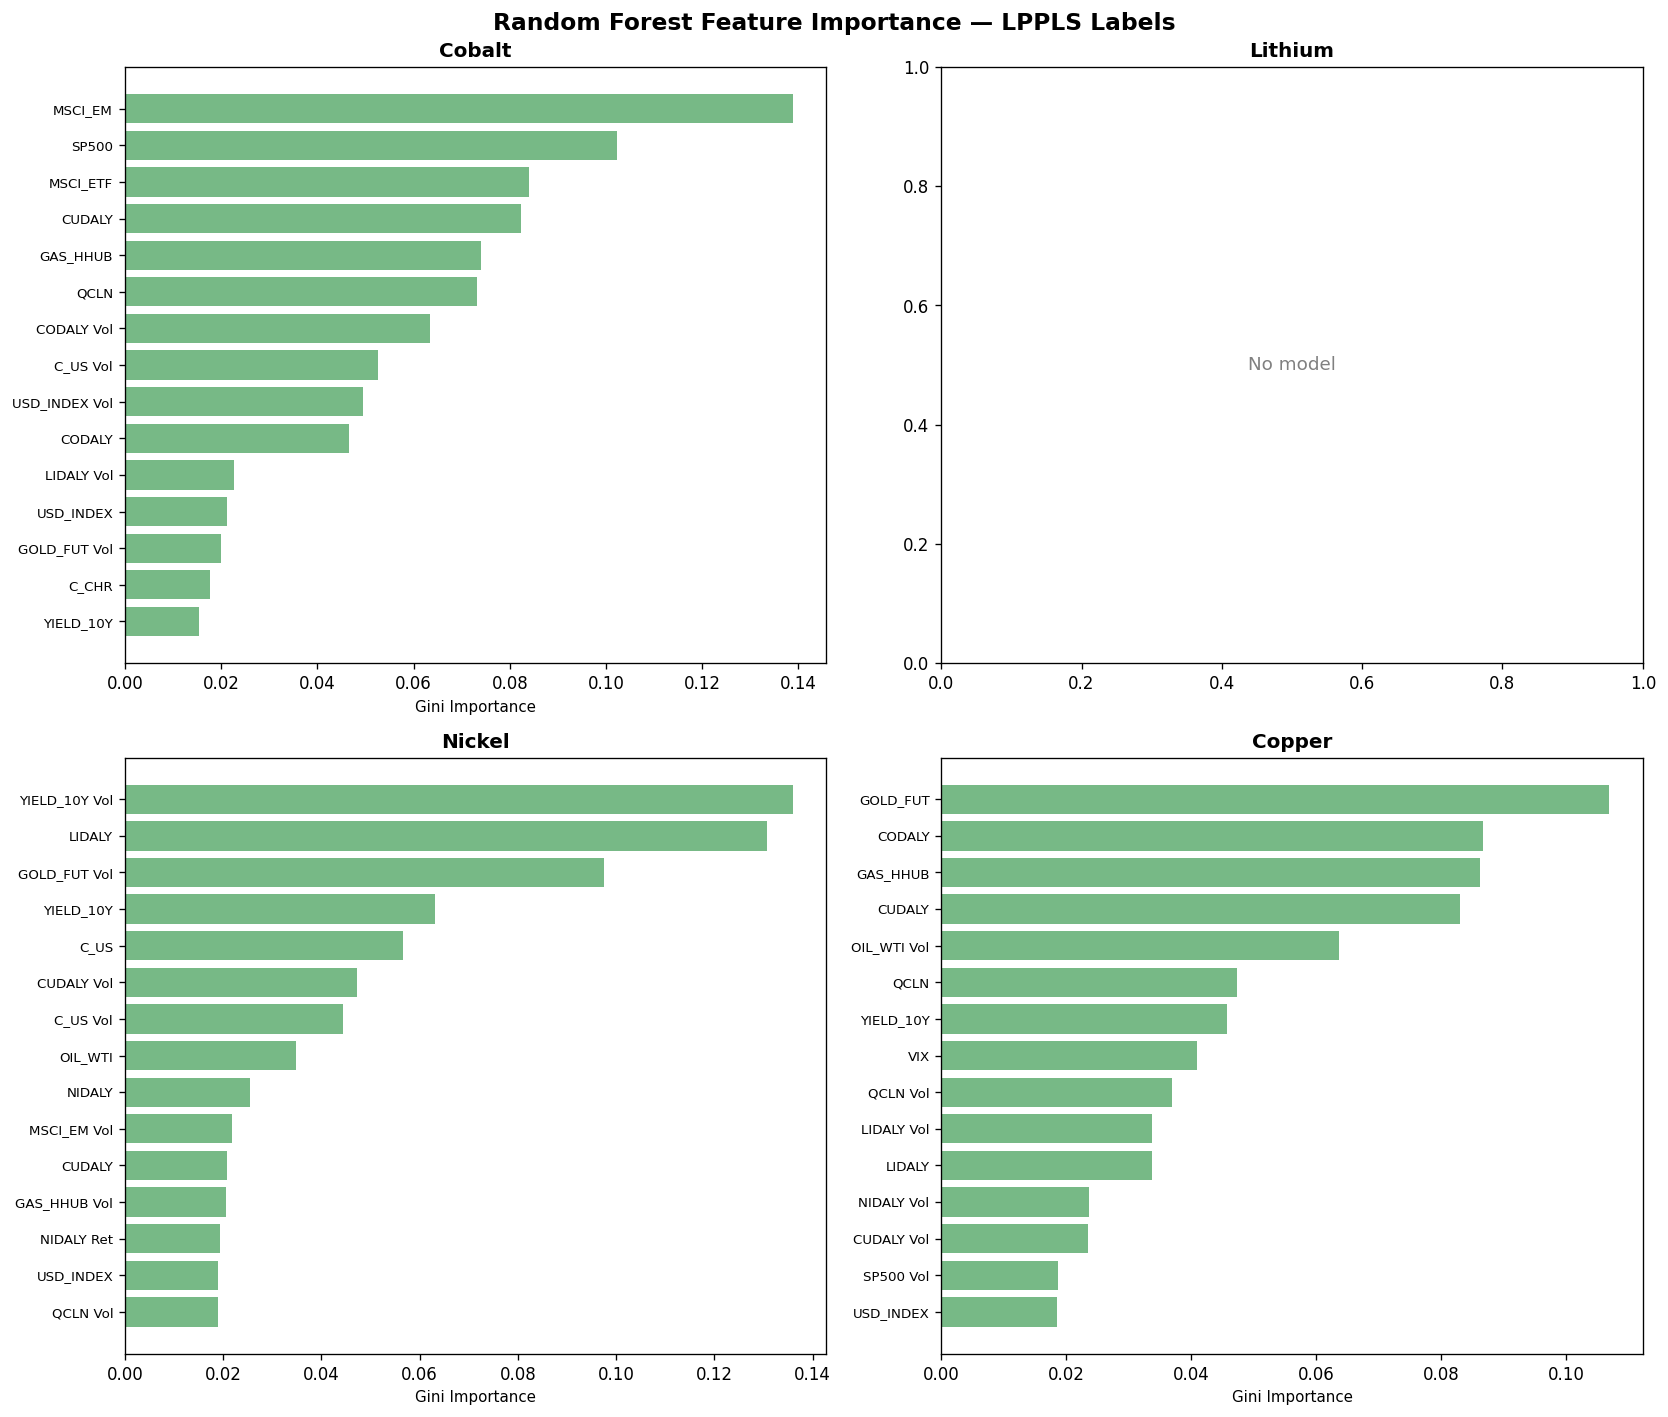

In [14]:
# --- Random Forest Gini Importance ---
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
for idx, (metal, col) in enumerate(metal_configs.items()):
    ax = axes.flat[idx]
    if metal not in rf_models:
        ax.text(0.5, 0.5, 'No model', ha='center', va='center',
                transform=ax.transAxes, fontsize=11, color='grey')
        ax.set_title(metal, fontsize=12, fontweight='bold')
        continue
    info    = rf_models[metal]
    imp     = info['model'].feature_importances_
    top_k   = 15
    top_idx = np.argsort(imp)[-top_k:]
    names   = [clean_name(info['features'][i]) for i in top_idx]

    ax.barh(range(top_k), imp[top_idx], color='#55A868', alpha=0.8)
    ax.set_yticks(range(top_k))
    ax.set_yticklabels(names, fontsize=8)
    ax.set_title(metal, fontsize=12, fontweight='bold')
    ax.set_xlabel('Gini Importance', fontsize=9)

plt.suptitle('Random Forest Feature Importance — LPPLS Labels', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/lppls_rf_importance.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()


## Summary

| Item | Status |
|---|---|
| Labels source | LPPLS confidence ≥ 0.3, trend-filtered (`lppls_data_prep.ipynb`) |
| Time-series CV | ✅ Expanding window, no future leakage |
| Class imbalance | ✅ `balanced` weights / `is_unbalance=True` |
| Empty fold guard | ✅ Skips folds with <5 training bubbles; returns empty arrays gracefully |
| ROC guard | ✅ `try/except` around `roc_curve` for single-class test sets |
| Hyperparameter tuning | ✅ Grid (LASSO) + randomized search (RF, LightGBM) |
| Feature importance | ✅ SHAP, LASSO coefs, Gini (graceful "no model" fallback) |

**Interpreting results under sparse LPPLS labels:**
LPPLS typically flags 1–2% of days as bubbles (vs up to 50% for GSADF on Lithium).
With few positive examples per fold, AUC estimates are volatile — high variance across runs
is expected. A metal whose AUC is near 0.5 may genuinely be hard to predict from
the available macro/market features, not necessarily a model failure.

**Outputs saved to `outputs/lppls_*.png`**
